# NASA Exoplanet Archive 数据探索

**目标**: 探索系外行星数据集，为天文黑客松项目做准备

**数据源**: NASA Exoplanet Archive (pscomppars表)

**关联方向**:
- 系外行星候选验证Agent
- 宜居性推理引擎
- 天文自然语言数据接口
- 光变曲线分类器

## 1. 环境准备

In [1]:
# 安装依赖（如果需要）
# !pip install astroquery pandas matplotlib seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置图表风格
sns.set_theme(style="whitegrid")
print("环境准备完成!")

Matplotlib is building the font cache; this may take a moment.


/var/folders/rt/r6j91ry93hd0gfpsvfcxvt8r0000gn/T/ipykernel_20033/3002380925.py:5: DeprecationWarning: the ``nasa_exoplanet_archive`` module has been moved to astroquery.ipac.nexsci.nasa_exoplanet_archive, please update your imports.
  from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive


环境准备完成!


## 2. 数据获取

In [3]:
# 查询所有确认行星的关键参数
query_columns = """
    pl_name, hostname, discoverymethod, disc_year, disc_facility,
    pl_orbper, pl_rade, pl_bmasse, pl_eqt,
    st_teff, st_rad, st_mass, st_logg,
    sy_dist, sy_vmag, sy_kmag
"""

print("正在查询NASA Exoplanet Archive...")
table = NasaExoplanetArchive.query_criteria(
    table="pscomppars",
    select=query_columns
)

# 转为DataFrame
df = table.to_pandas()
print(f"查询完成! 共获取 {len(df)} 条记录")
print(f"列数: {len(df.columns)}")

正在查询NASA Exoplanet Archive...


查询完成! 共获取 6298 条记录
列数: 16


In [4]:
# 查看数据结构
print("数据列:")
print(df.columns.tolist())
print("\n数据类型:")
print(df.dtypes)

数据列:
['pl_name', 'hostname', 'discoverymethod', 'disc_year', 'disc_facility', 'pl_orbper', 'pl_rade', 'pl_bmasse', 'pl_eqt', 'st_teff', 'st_rad', 'st_mass', 'st_logg', 'sy_dist', 'sy_vmag', 'sy_kmag']

数据类型:
pl_name                str
hostname               str
discoverymethod        str
disc_year            int32
disc_facility          str
pl_orbper          float64
pl_rade            float64
pl_bmasse          float64
pl_eqt             float64
st_teff            float64
st_rad             float64
st_mass            float64
st_logg            float64
sy_dist            float64
sy_vmag            float64
sy_kmag            float64
dtype: object


In [5]:
# 查看前几行
df.head(10)

,pl_name,hostname,discoverymethod,disc_year,disc_facility,pl_orbper,pl_rade,pl_bmasse,pl_eqt,st_teff,st_rad,st_mass,st_logg,sy_dist,sy_vmag,sy_kmag
0,HD 77946 b,HD 77946,Transit,2024,Transiting Exoplanet Survey Satellite (TESS),6.527363,2.896461,10.90000,1128.86,6007.00,1.317400,1.1973,4.2760,99.4510,8.990,7.622
1,LHS 1478 b,LHS 1478,Transit,2021,Transiting Exoplanet Survey Satellite (TESS),1.949538,1.242000,2.33000,595.00,3381.00,0.246000,0.2360,4.8700,18.2276,13.304,8.767
2,TOI-5143 c,TOI-5143,Transit,2025,Transiting Exoplanet Survey Satellite (TESS),5.209712,16.253022,NaN,904.48,5183.00,0.852000,0.8640,4.5140,181.3800,11.935,9.980
3,TOI-815 c,TOI-815,Transit,2024,Transiting Exoplanet Survey Satellite (TESS),34.976145,2.620000,23.50000,469.00,4869.00,0.770000,0.7760,4.5100,59.7117,10.217,7.999
4,TIC 67686059 b,TIC 67686059,Transit,2026,Transiting Exoplanet Survey Satellite (TESS),3.521635,2.591259,7.23000,NaN,5090.09,0.820458,0.8600,4.5535,249.2030,12.992,10.924
5,WASP-171 b,WASP-171,Transit,2019,WASP-South,3.818624,10.984820,344.52772,1642.00,5965.00,1.637000,1.1710,4.0800,757.8400,12.612,11.104
6,Kepler-80 c,Kepler-80,Transit,2012,Kepler,9.523550,2.740000,6.74000,495.00,4540.00,0.678000,0.7300,4.6390,369.4510,15.230,12.253
7,HATS-49 b,HATS-49,Transit,2020,HATSouth,4.148047,8.574885,112.19399,834.80,4405.00,0.697700,0.7133,4.6036,324.4130,14.988,11.938
8,EPIC 206317286 b,EPIC 206317286,Transit,2019,K2,1.582520,0.960000,0.84000,NaN,4752.00,0.669000,0.7110,4.5960,314.3500,14.005,11.635
9,Kepler-925 b,Kepler-925,Transit,2016,Kepler,33.867853,2.340000,6.08000,394.00,4673.00,0.720000,0.7700,4.6200,611.1150,16.025,13.339


In [6]:
# 基本统计
print("数据集概览:")
print(f"确认行星总数: {len(df)}")
print(f"独特恒星系统: {df['hostname'].nunique()}")
print(f"发现年份范围: {df['disc_year'].min():.0f} - {df['disc_year'].max():.0f}")
print(f"\n缺失值统计:")
print(df.isnull().sum())

数据集概览:
确认行星总数: 6298
独特恒星系统: 4716
发现年份范围: 0 - 2026

缺失值统计:
pl_name              0
hostname             0
discoverymethod      0
disc_year            0
disc_facility        0
pl_orbper          340
pl_rade             50
pl_bmasse           31
pl_eqt             521
st_teff            294
st_rad             318
st_mass              9
st_logg            322
sy_dist             27
sy_vmag            299
sy_kmag            286
dtype: int64


## 3. 发现方法分析

各发现方法的行星数量:
discoverymethod
Transit                          4653
Radial Velocity                  1186
Microlensing                      278
Imaging                            97
Transit Timing Variations          41
Eclipse Timing Variations          17
Orbital Brightness Modulation       9
Pulsar Timing                       8
Astrometry                          6
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64


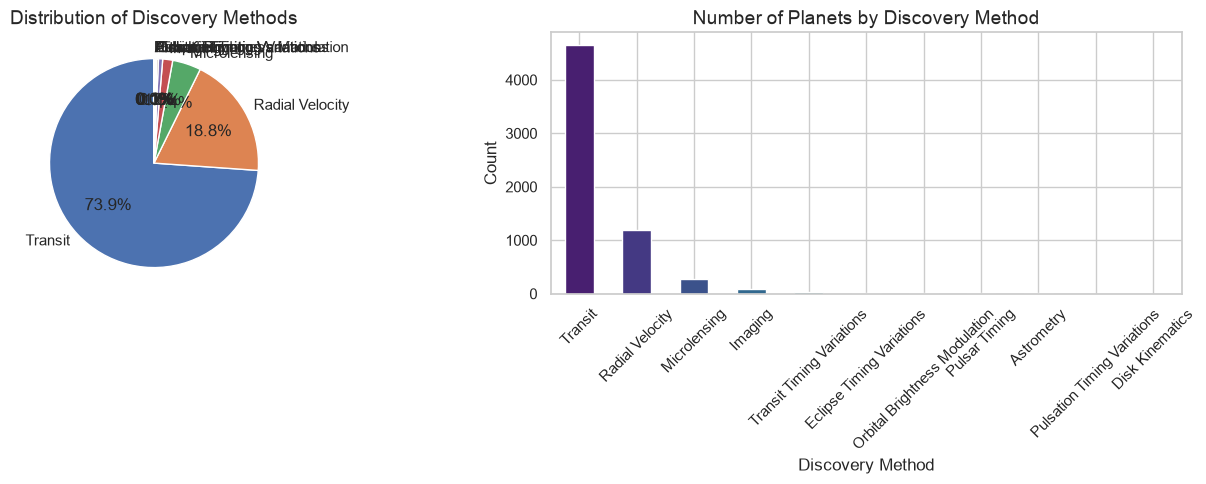

In [7]:
# 按发现方法统计
method_counts = df['discoverymethod'].value_counts()
print("各发现方法的行星数量:")
print(method_counts)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 饼图
axes[0].pie(method_counts.values, labels=method_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribution of Discovery Methods', fontsize=14)

# 柱状图
method_counts.plot(kind='bar', ax=axes[1], color=sns.color_palette("viridis", len(method_counts)))
axes[1].set_title('Number of Planets by Discovery Method', fontsize=14)
axes[1].set_xlabel('Discovery Method')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. 发现时间趋势

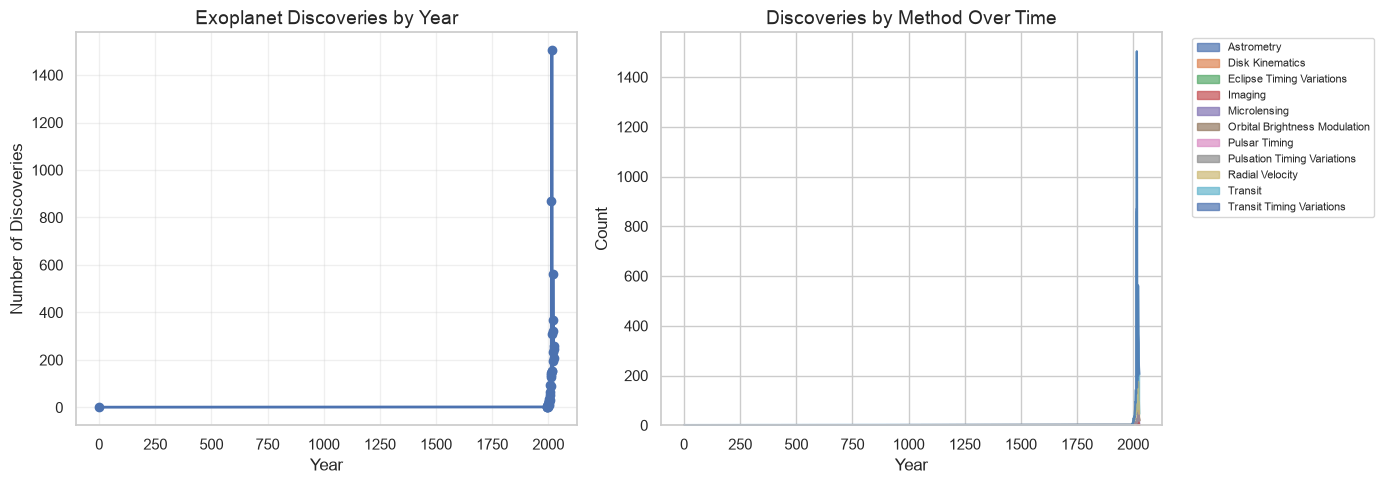


发现高峰年份: 2016年 (1504颗行星)


In [8]:
# 按年份统计发现数量
yearly_counts = df.groupby('disc_year').size().reset_index(name='count')

# 按发现方法分组
yearly_method = df.groupby(['disc_year', 'discoverymethod']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 总发现趋势
axes[0].plot(yearly_counts['disc_year'], yearly_counts['count'], 'b-o', linewidth=2)
axes[0].fill_between(yearly_counts['disc_year'], yearly_counts['count'], alpha=0.3)
axes[0].set_title('Exoplanet Discoveries by Year', fontsize=14)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Discoveries')
axes[0].grid(True, alpha=0.3)

# 按方法堆叠
yearly_method.plot(kind='area', stacked=True, ax=axes[1], alpha=0.7)
axes[1].set_title('Discoveries by Method Over Time', fontsize=14)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# 关键年份
peak_year = yearly_counts.loc[yearly_counts['count'].idxmax()]
print(f"\n发现高峰年份: {peak_year['disc_year']:.0f}年 ({peak_year['count']}颗行星)")

## 5. 行星参数分布

有效数据: 5738 条记录


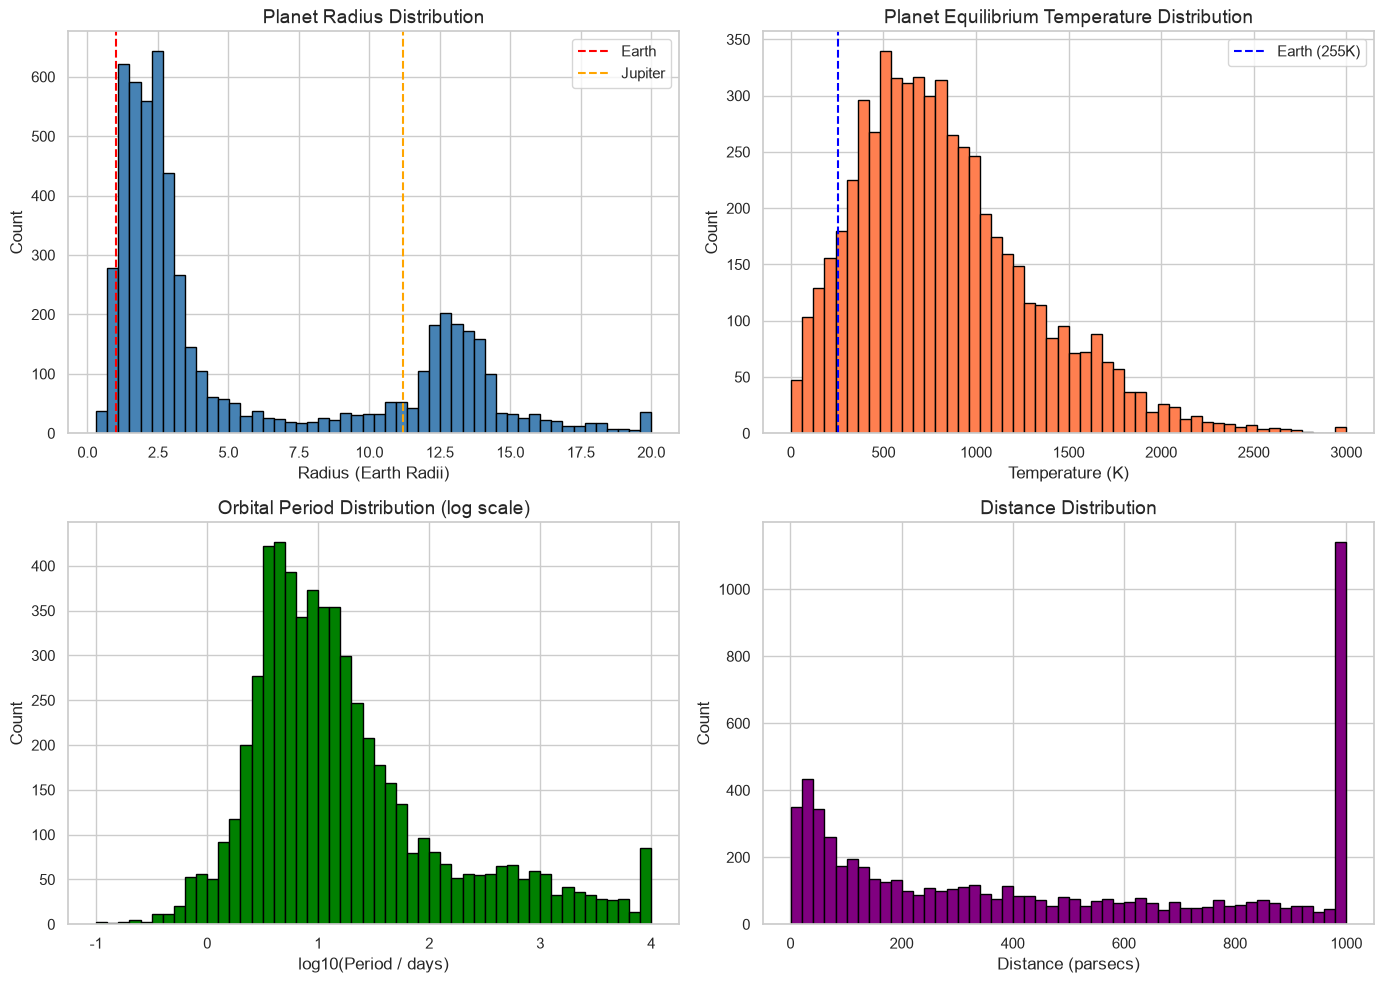

In [9]:
# 清理数据用于可视化
df_clean = df.dropna(subset=['pl_rade', 'pl_eqt']).copy()
print(f"有效数据: {len(df_clean)} 条记录")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 行星半径分布
axes[0, 0].hist(df_clean['pl_rade'].clip(0, 20), bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Planet Radius Distribution', fontsize=14)
axes[0, 0].set_xlabel('Radius (Earth Radii)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(x=1, color='red', linestyle='--', label='Earth')
axes[0, 0].axvline(x=11.2, color='orange', linestyle='--', label='Jupiter')
axes[0, 0].legend()

# 2. 平衡温度分布
axes[0, 1].hist(df_clean['pl_eqt'].clip(0, 3000), bins=50, color='coral', edgecolor='black')
axes[0, 1].set_title('Planet Equilibrium Temperature Distribution', fontsize=14)
axes[0, 1].set_xlabel('Temperature (K)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].axvline(x=255, color='blue', linestyle='--', label='Earth (255K)')
axes[0, 1].legend()

# 3. 轨道周期分布 (对数坐标)
df_period = df.dropna(subset=['pl_orbper'])
axes[1, 0].hist(np.log10(df_period['pl_orbper'].clip(0.1, 10000)), bins=50, color='green', edgecolor='black')
axes[1, 0].set_title('Orbital Period Distribution (log scale)', fontsize=14)
axes[1, 0].set_xlabel('log10(Period / days)')
axes[1, 0].set_ylabel('Count')

# 4. 距离分布
df_dist = df.dropna(subset=['sy_dist'])
axes[1, 1].hist(df_dist['sy_dist'].clip(0, 1000), bins=50, color='purple', edgecolor='black')
axes[1, 1].set_title('Distance Distribution', fontsize=14)
axes[1, 1].set_xlabel('Distance (parsecs)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 6. 宜居带行星筛选

In [10]:
# 宜居带粗略筛选: 温度在200-300K之间，半径在0.5-2地球半径之间
habitable = df_clean[
    (df_clean['pl_eqt'] >= 200) & 
    (df_clean['pl_eqt'] <= 300) & 
    (df_clean['pl_rade'] >= 0.5) & 
    (df_clean['pl_rade'] <= 2.0)
].copy()

print(f"宜居带候选行星: {len(habitable)} 颗")
print("\n宜居带行星列表:")
habitable_sorted = habitable.sort_values('pl_rade')
habitable_sorted[['pl_name', 'hostname', 'pl_rade', 'pl_eqt', 'sy_dist', 'discoverymethod']].head(20)

宜居带候选行星: 49 颗

宜居带行星列表:


,pl_name,hostname,pl_rade,pl_eqt,sy_dist,discoverymethod
2670,Proxima Cen d,Proxima Cen,0.692,282.00,1.301190,Radial Velocity
3314,TRAPPIST-1 d,TRAPPIST-1,0.788,286.20,12.429889,Transit
6032,Kepler-138 e,Kepler-138,0.797,292.00,66.862400,Transit Timing Variations
2339,TRAPPIST-1 e,TRAPPIST-1,0.920,249.70,12.429889,Transit
508,TOI-700 e,TOI-700,0.953,272.90,31.126500,Transit
1049,Proxima Cen b,Proxima Cen,1.020,218.00,1.301190,Radial Velocity
3959,Teegarden's Star c,Teegarden's Star,1.020,209.00,3.830780,Radial Velocity
3251,GJ 1002 b,GJ 1002,1.030,230.90,4.848670,Radial Velocity
4488,TRAPPIST-1 f,TRAPPIST-1,1.045,217.70,12.429889,Transit
3714,Teegarden's Star b,Teegarden's Star,1.050,277.00,3.830780,Radial Velocity


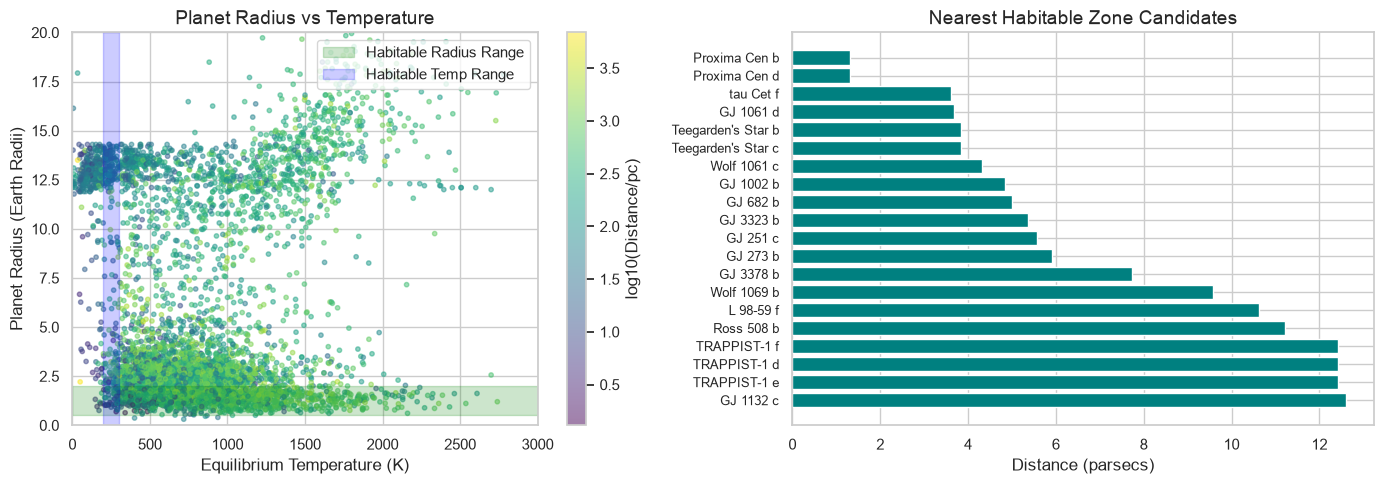

In [11]:
# 宜居带行星可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 半径 vs 温度散点图
scatter = axes[0].scatter(
    df_clean['pl_eqt'], 
    df_clean['pl_rade'],
    c=np.log10(df_clean['sy_dist'].clip(1, 10000)),
    cmap='viridis',
    alpha=0.5,
    s=10
)
# 标记宜居带
axes[0].axhspan(0.5, 2.0, alpha=0.2, color='green', label='Habitable Radius Range')
axes[0].axvspan(200, 300, alpha=0.2, color='blue', label='Habitable Temp Range')
axes[0].set_xlabel('Equilibrium Temperature (K)', fontsize=12)
axes[0].set_ylabel('Planet Radius (Earth Radii)', fontsize=12)
axes[0].set_title('Planet Radius vs Temperature', fontsize=14)
axes[0].set_xlim(0, 3000)
axes[0].set_ylim(0, 20)
axes[0].legend(loc='upper right')
plt.colorbar(scatter, ax=axes[0], label='log10(Distance/pc)')

# 宜居带行星按距离排序
habitable_near = habitable.sort_values('sy_dist').head(20)
axes[1].barh(range(len(habitable_near)), habitable_near['sy_dist'], color='teal')
axes[1].set_yticks(range(len(habitable_near)))
axes[1].set_yticklabels(habitable_near['pl_name'], fontsize=9)
axes[1].set_xlabel('Distance (parsecs)', fontsize=12)
axes[1].set_title('Nearest Habitable Zone Candidates', fontsize=14)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. 恒星参数分析

有恒星参数的记录: 5977 条


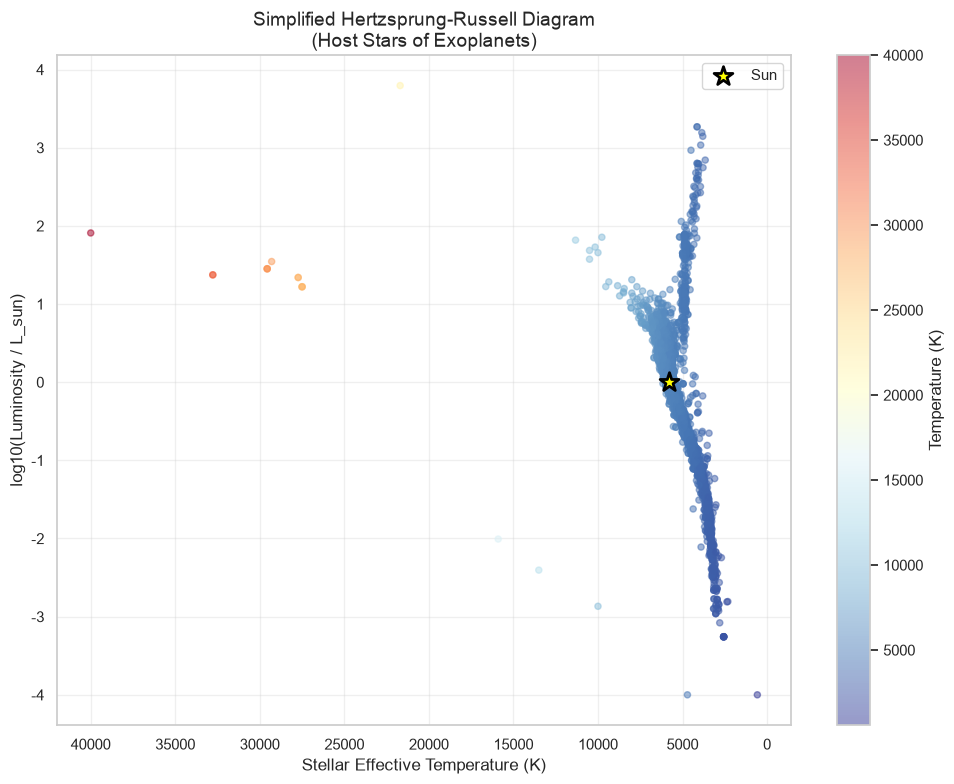

In [12]:
# 清理恒星数据
df_stars = df.dropna(subset=['st_teff', 'st_rad']).copy()
print(f"有恒星参数的记录: {len(df_stars)} 条")

# 简化赫罗图 (Temperature vs Luminosity proxy)
fig, ax = plt.subplots(figsize=(10, 8))

# 计算光度代理 (R^2 * T^4)
df_stars['luminosity_proxy'] = (df_stars['st_rad'] ** 2) * ((df_stars['st_teff'] / 5778) ** 4)

scatter = ax.scatter(
    df_stars['st_teff'],
    np.log10(df_stars['luminosity_proxy'].clip(1e-4, 1e6)),
    c=df_stars['st_teff'],
    cmap='RdYlBu_r',
    alpha=0.5,
    s=20
)

# 标记太阳
ax.scatter(5778, 0, color='yellow', s=200, marker='*', edgecolors='black', linewidth=2, label='Sun', zorder=5)

ax.set_xlabel('Stellar Effective Temperature (K)', fontsize=12)
ax.set_ylabel('log10(Luminosity / L_sun)', fontsize=12)
ax.set_title('Simplified Hertzsprung-Russell Diagram\n(Host Stars of Exoplanets)', fontsize=14)
ax.invert_xaxis()  # HR图惯例：高温在左
ax.legend()
plt.colorbar(scatter, label='Temperature (K)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. 发现设施分析

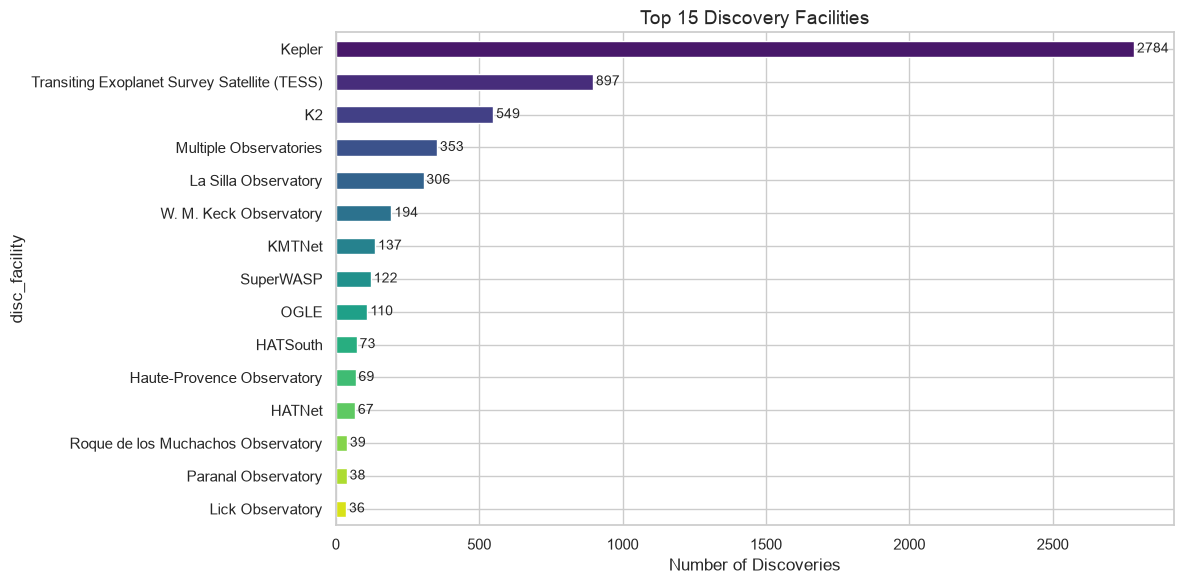


主要发现设施:
disc_facility
Kepler                                          2784
Transiting Exoplanet Survey Satellite (TESS)     897
K2                                               549
Multiple Observatories                           353
La Silla Observatory                             306
W. M. Keck Observatory                           194
KMTNet                                           137
SuperWASP                                        122
OGLE                                             110
HATSouth                                          73
Haute-Provence Observatory                        69
HATNet                                            67
Roque de los Muchachos Observatory                39
Paranal Observatory                               38
Lick Observatory                                  36
Name: count, dtype: int64


In [13]:
# 按发现设施统计
facility_counts = df['disc_facility'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
facility_counts.plot(kind='barh', color=sns.color_palette("viridis", len(facility_counts)))
ax.set_xlabel('Number of Discoveries', fontsize=12)
ax.set_title('Top 15 Discovery Facilities', fontsize=14)
ax.invert_yaxis()

# 添加数值标签
for i, v in enumerate(facility_counts.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n主要发现设施:")
print(facility_counts)

## 9. 多行星系统分析

多行星系统统计:
planet_count
1    3663
2     709
3     219
4      82
5      29
6      12
7       1
8       1
Name: count, dtype: int64


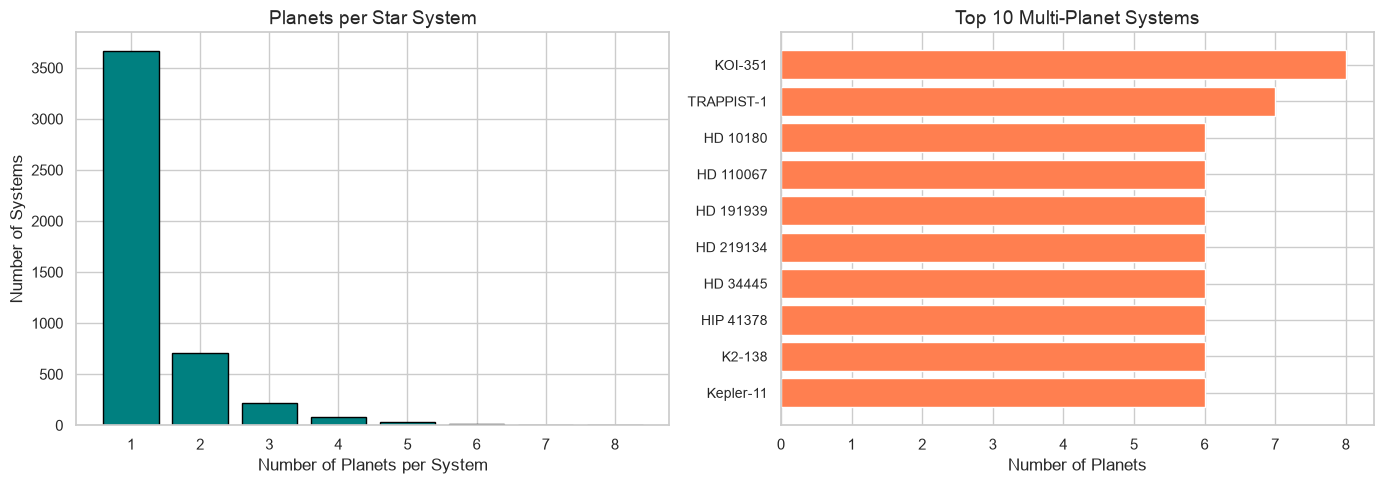

In [14]:
# 统计每颗恒星的行星数量
planets_per_star = df.groupby('hostname').size().reset_index(name='planet_count')
system_counts = planets_per_star['planet_count'].value_counts().sort_index()

print("多行星系统统计:")
print(system_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 行星数量分布
axes[0].bar(system_counts.index, system_counts.values, color='teal', edgecolor='black')
axes[0].set_xlabel('Number of Planets per System', fontsize=12)
axes[0].set_ylabel('Number of Systems', fontsize=12)
axes[0].set_title('Planets per Star System', fontsize=14)
axes[0].set_xticks(range(1, max(system_counts.index)+1))

# 找到行星最多的系统
top_systems = planets_per_star.nlargest(10, 'planet_count')
axes[1].barh(range(len(top_systems)), top_systems['planet_count'], color='coral')
axes[1].set_yticks(range(len(top_systems)))
axes[1].set_yticklabels(top_systems['hostname'], fontsize=10)
axes[1].set_xlabel('Number of Planets', fontsize=12)
axes[1].set_title('Top 10 Multi-Planet Systems', fontsize=14)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 10. 数据导出与下一步

In [15]:
# 导出处理后的数据
output_path = "../data/exoplanets_processed.csv"
df.to_csv(output_path, index=False)
print(f"数据已导出到: {output_path}")
print(f"导出记录数: {len(df)}")

# 导出宜居带候选
habitable_path = "../data/habitable_candidates.csv"
habitable.to_csv(habitable_path, index=False)
print(f"\n宜居带候选已导出到: {habitable_path}")
print(f"宜居带候选数: {len(habitable)}")

数据已导出到: ../data/exoplanets_processed.csv
导出记录数: 6298

宜居带候选已导出到: ../data/habitable_candidates.csv
宜居带候选数: 49


## 11. 黑客松方向关联

基于以上探索，以下是可直接对接的黑客松方向：

### 方向一: 天文自然语言数据接口
- 本notebook的查询逻辑可直接封装为Agent工具
- 用户输入自然语言 → LLM生成类似本notebook的查询 → 返回结果

### 方向二: 系外行星候选验证Agent
- 利用行星参数分布建立物理约束
- 输入新发现的行星参数 → 检查是否在合理范围内

### 方向三: 宜居性推理引擎
- 基于温度-半径筛选逻辑扩展为多因素评估
- 加入恒星类型、轨道偏心率、潮汐锁定等因素

### 方向四: 数据质量评估Agent
- 本notebook展示了缺失值分析
- 可扩展为自动化数据质量报告生成

In [16]:
# 数据摘要 - 用于后续Agent开发
summary = {
    "total_planets": len(df),
    "unique_systems": df['hostname'].nunique(),
    "year_range": f"{df['disc_year'].min():.0f}-{df['disc_year'].max():.0f}",
    "habitable_candidates": len(habitable),
    "discovery_methods": df['discoverymethod'].nunique(),
    "top_method": df['discoverymethod'].mode()[0],
    "nearest_habitable": habitable.sort_values('sy_dist').iloc[0]['pl_name'] if len(habitable) > 0 else None
}

print("数据集摘要 (可用于Agent上下文):")
for k, v in summary.items():
    print(f"  {k}: {v}")

数据集摘要 (可用于Agent上下文):
  total_planets: 6298
  unique_systems: 4716
  year_range: 0-2026
  habitable_candidates: 49
  discovery_methods: 11
  top_method: Transit
  nearest_habitable: Proxima Cen b
